In [5]:
import torch
from torch import nn
from torch import optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Learned Parameters:
weight [[2.780015]]
bias [4.2170124]


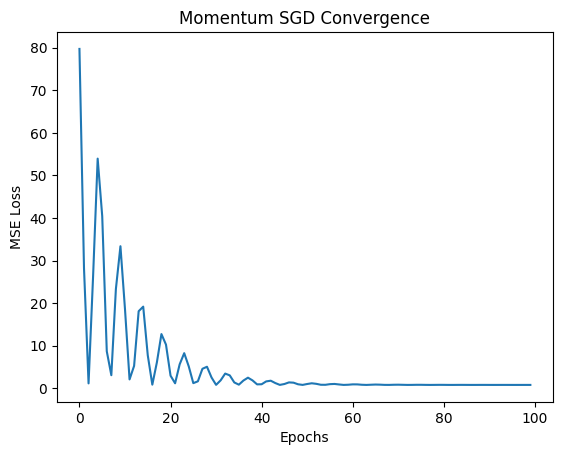

In [13]:
# Generate Synthetic Linear Data
# We create data using the equation:
# y = 4 + 3x + noise

np.random.seed(42)

X = 2 * np.random.rand(100, 1)               # 100 random x values
y = 4 + 3 * X + np.random.randn(100, 1)     # true linear relation + noise

# Convert NumPy arrays to Torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)


# Define Linear Regression Model
# 1 input feature → 1 output value
# Internally it creates:
# weight (w) and bias (b)

model = torch.nn.Linear(1, 1)

# Define Loss Function and Optimizer
criterion = torch.nn.MSELoss()

# momentum = beta (velocity factor)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9
)

# Training Loop
epochs = 100
loss_history = []

for epoch in range(epochs):
    
    # Step 1: Clear previous gradients
    optimizer.zero_grad()
    
    # Step 2: Forward pass (prediction)
    predictions = model(X_tensor)
    
    # Step 3: Compute loss
    loss = criterion(predictions, y_tensor)
    
    # Step 4: Backpropagation
    loss.backward()
    
    # Step 5: Update parameters using Momentum SGD
    optimizer.step()
    
    # Store loss for plotting
    loss_history.append(loss.item())

# Print Learned Parameters
print("Learned Parameters:")
for name, param in model.named_parameters():
    print(name, param.data.numpy())

# Plot Loss Curve
plt.figure()
plt.plot(range(epochs), loss_history)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Momentum SGD Convergence")
plt.show()